In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [6]:
import os
import sys
# Changing directory for VSCode notebook
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
# Load the backend
backend = emcee.backends.HDFBackend('emcee_backend.h5')

In [7]:
# Check if it has data
try:
    print(f"Iterations stored: {backend.iteration}")
    print(f"Shape: {backend.shape}")
except AttributeError:
    print("Backend is empty - sampler hasn't stored any results yet")


Iterations stored: 50000
Shape: (32, 5)


In [8]:
# Get the chain
samples = backend.get_chain()
log_prob = backend.get_log_prob()

In [12]:
tau = backend.get_autocorr_time()
tau

/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


array([nan, nan, nan, nan, nan])

In [16]:
np.var(samples, axis=(0,1))

array([9.89394409e-09, 5.97700838e-09, 1.36647526e-08, 1.41235518e-08,
       7.98608883e-09])

In [15]:
# Test a few positions
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Changing directory for VSCode notebook
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
# import loglike
# import modeselector
# import parismc
# import gc
# import pickle
import cupy as cp

import scipy.optimize as opt
import emcee



# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 2 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

print("Generate data...")
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

def loglike(params):
    logm1, logm2, a, p0, e0 = params
    m1 = 10**logm1
    m2 = 10**logm2

    htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                         Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
    res = data - htemp
    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)
    calc_loglike = -0.5 * inner_res

    # return calc_loglike
    # Using cupy to convert to float
    return float(cp.asnumpy(calc_loglike)) 

def log_prior(params):    
    bounds = [
        (5.9999650899e+00, 6.0000349101e+00),  # logm1
        (1.4771002185e+00, 1.4771422909e+00),  # logm2
        (6.9993760164e-01, 7.0006239836e-01),  # a
        (7.4996582212e+00, 7.5003417788e+00),  # p0
        (3.9998409234e-01, 4.0001590766e-01),  # e0
    ]
    
    for param, (lower, upper) in zip(params, bounds):
        if not (lower <= param <= upper):
            return -np.inf
    
    return 0.0

def logprob(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike(params)
test_params = [np.log10(1e6), np.log10(30), 0.7, 7.5, 0.4]
print("Test loglike:", loglike(test_params))
print("Test logprob:", logprob(test_params))

DEBUG:few:Configuration file not found in '/nfs/home/svu/e1498138/localgit/FEWNEW/work/few.ini'
DEBUG:few:Configuration file not found in '/home/svu/e1498138/.config/few.ini'
DEBUG:few:Configuration file not found in '/etc/xdg/few/v0.0/few.ini'
DEBUG:few:ConfigInitialization: final configuration entries are
DEBUG:few: ignore_cfg=False (from: ConfigSource.DEFAULT)
DEBUG:few: ignore_env=False (from: ConfigSource.DEFAULT)
DEBUG:few: config_file=None (from: ConfigSource.DEFAULT)
DEBUG:few: log_level=20 (from: ConfigSource.SETTER)
DEBUG:few: log_format=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_registry_path=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_storage_path=/nfs/home/svu/e1498138/localgit/FEW_SM/FastEMRIWaveforms/src/few/data (from: ConfigSource.DEFAULT)
DEBUG:few: file_download_path=/nfs/home/svu/e1498138/localgit/FEW_SM/FastEMRIWaveforms/src/few/data (from: ConfigSource.DEFAULT)
DEBUG:few: file_allow_download=True (from: ConfigSource.DEFAULT)
DEBUG:few: file_integrity_

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Generate data...
Test loglike: -1.395150881782588e-19
Test logprob: -1.395150881782588e-19


In [9]:
# Get flat samples
discard = 5000  # burn-in steps to discard
thin = 50       # thinning factor
flat_samples = backend.get_chain(discard=discard, thin=thin, flat=True)


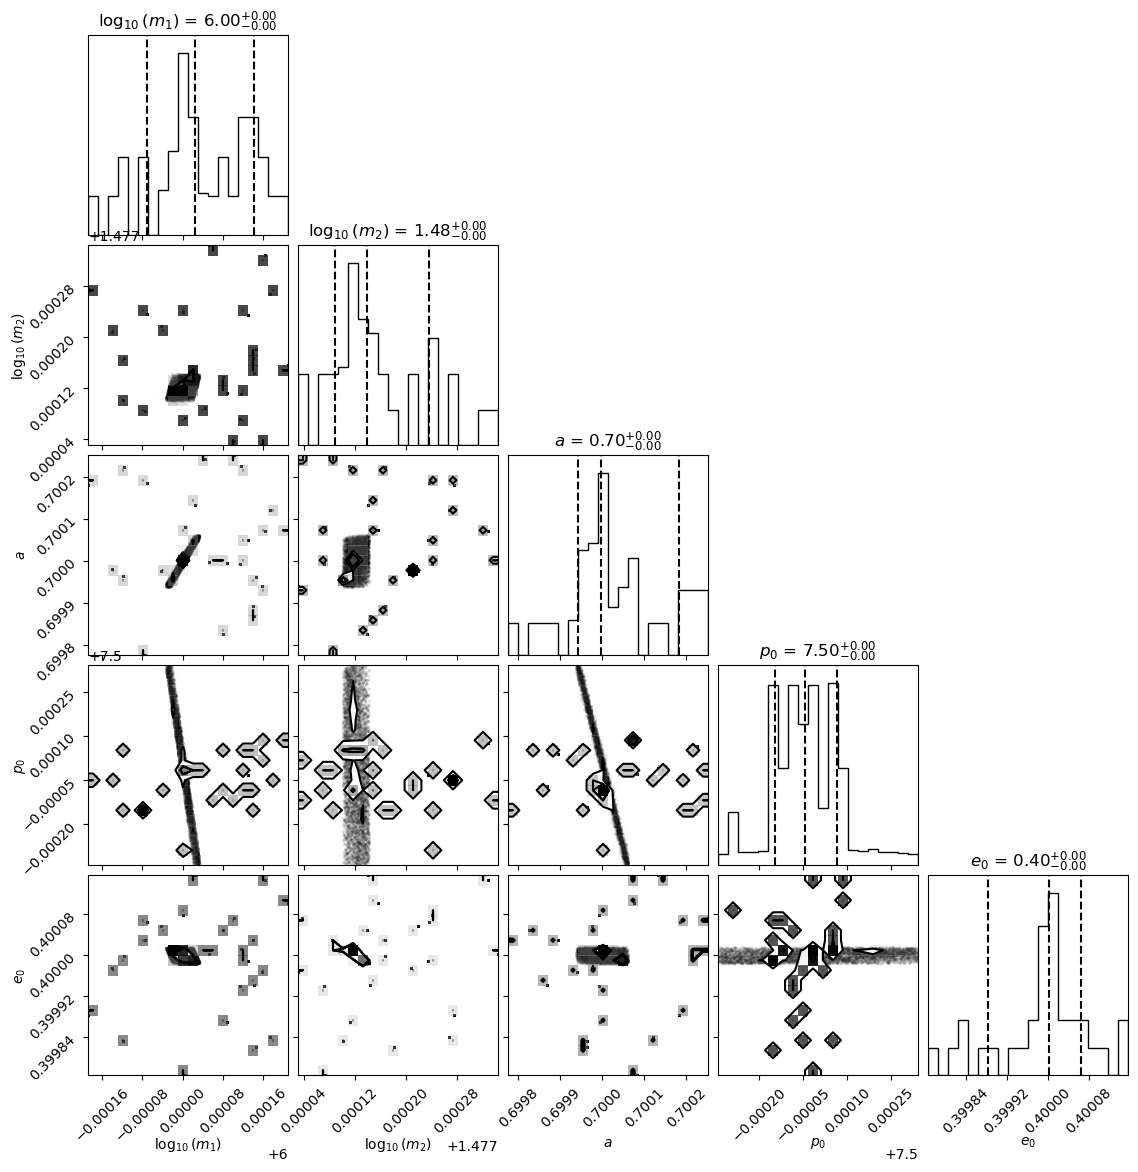

In [10]:
import corner
# Parameter labels
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']

# Create corner plot
fig = corner.corner(flat_samples, labels=labels, quantiles=[0.16, 0.5, 0.84],
                    show_titles=True, title_kwargs={"fontsize": 12})

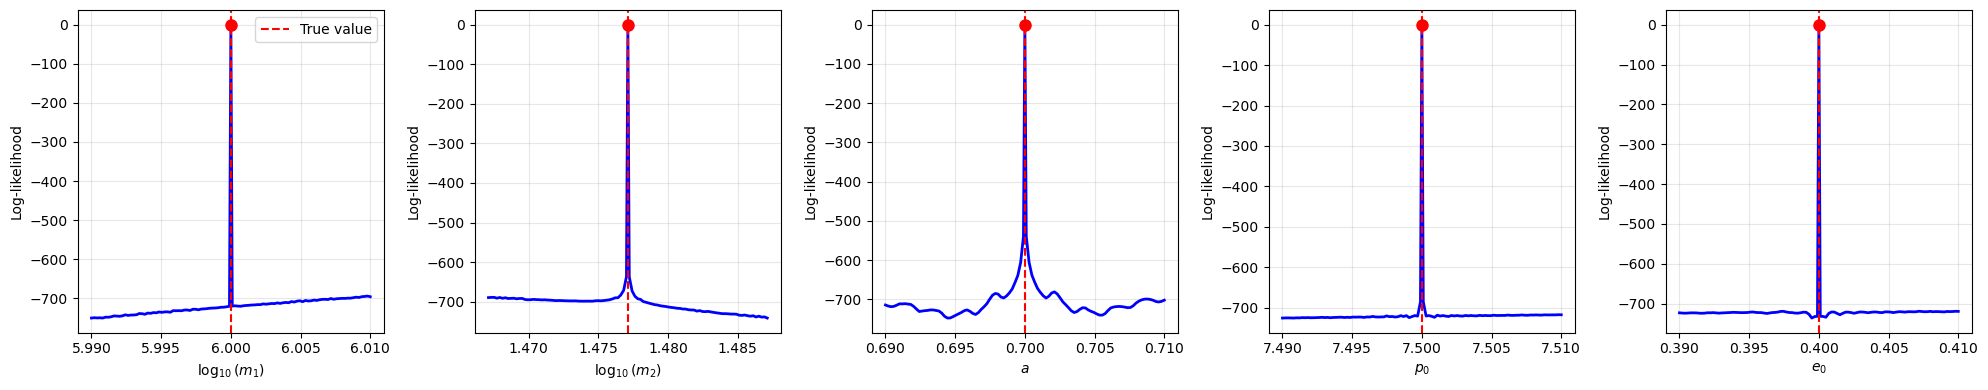

In [18]:
# 1D slices along each parameter
param_names = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
true_vals = [np.log10(m1), np.log10(m2), a, p0, e0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, name, true_val) in enumerate(zip(axes, param_names, true_vals)):
    # Create range for this parameter
    param_range = np.linspace(true_val - 0.01, true_val + 0.01, 100)
    
    # Ensure true value is included
    if true_val not in param_range:
        param_range = np.sort(np.append(param_range, true_val))
    
    # Compute likelihood along this parameter
    loglike_vals = []
    for val in param_range:
        params_test = true_vals.copy()
        params_test[i] = val
        loglike_vals.append(loglike(params_test))
    
    # Plot
    ax.plot(param_range, loglike_vals, 'b-', linewidth=2)
    ax.axvline(true_val, color='r', linestyle='--', label='True value')
    
    # Mark the true value point
    true_idx = np.argmin(np.abs(param_range - true_val))
    ax.plot(true_val, loglike_vals[true_idx], 'ro', markersize=8)
    
    ax.set_xlabel(name)
    ax.set_ylabel('Log-likelihood')
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.savefig('loglike_slices.png', dpi=150)
plt.show()